In [1]:
# Download the dataset zip file directly from the UCI machine learning repository
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Unzip the downloaded file so we can access the CSV
!unzip AirQualityUCI.zip

--2026-09-29 13:40:51--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip’

AirQualityUCI.zip       [  <=>               ]   1.47M  3.93MB/s    in 0.4s    

2026-09-29 13:40:52 (3.93 MB/s) - ‘AirQualityUCI.zip’ saved [1543989]

Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      


In [2]:
import pandas as pd
import numpy as np

# 1. Load the dataset
# The dataset uses European formatting: semicolons for separators and commas for decimals.
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')

# Clean up empty junk columns/rows at the end of the CSV
df = df.dropna(how='all', axis=1)
df = df.dropna(how='all', axis=0)

# 2. Handle Date and Time
# Combine the text from 'Date' and 'Time' into one proper Datetime column
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')

# Make the Datetime the index of our table (essential for time-series analysis)
df.set_index('Datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

# 3. Handle Missing Values
# The documentation says missing sensor readings are marked as -200.
# We must replace them with standard NaN (Not a Number)
df.replace(-200, np.nan, inplace=True)

print("Missing values before fixing:\n", df.isnull().sum())

# We use linear interpolation to fill the missing gaps based on surrounding hours
df.interpolate(method='time', inplace=True)

# If the very first row is missing data, back-fill it
df.bfill(inplace=True)

print("\nData Shape (Rows, Columns):", df.shape)
df.head()

Missing values before fixing:
 CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

Data Shape (Rows, Columns): (9357, 13)


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


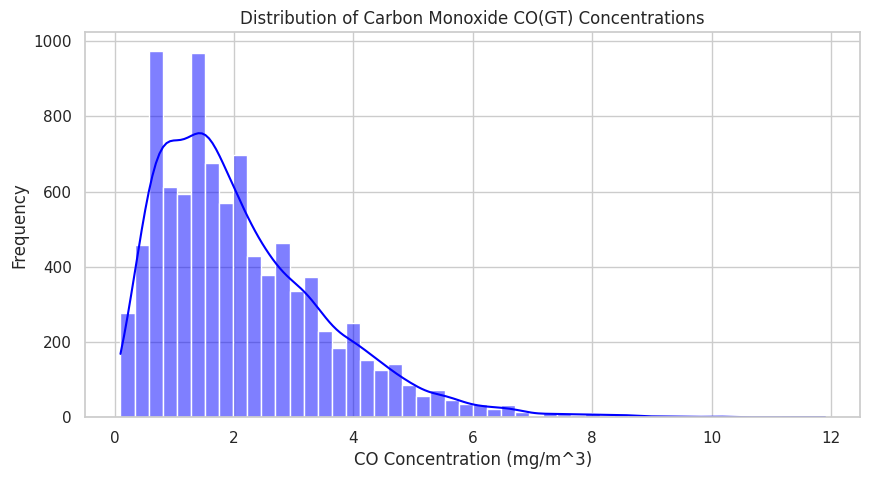

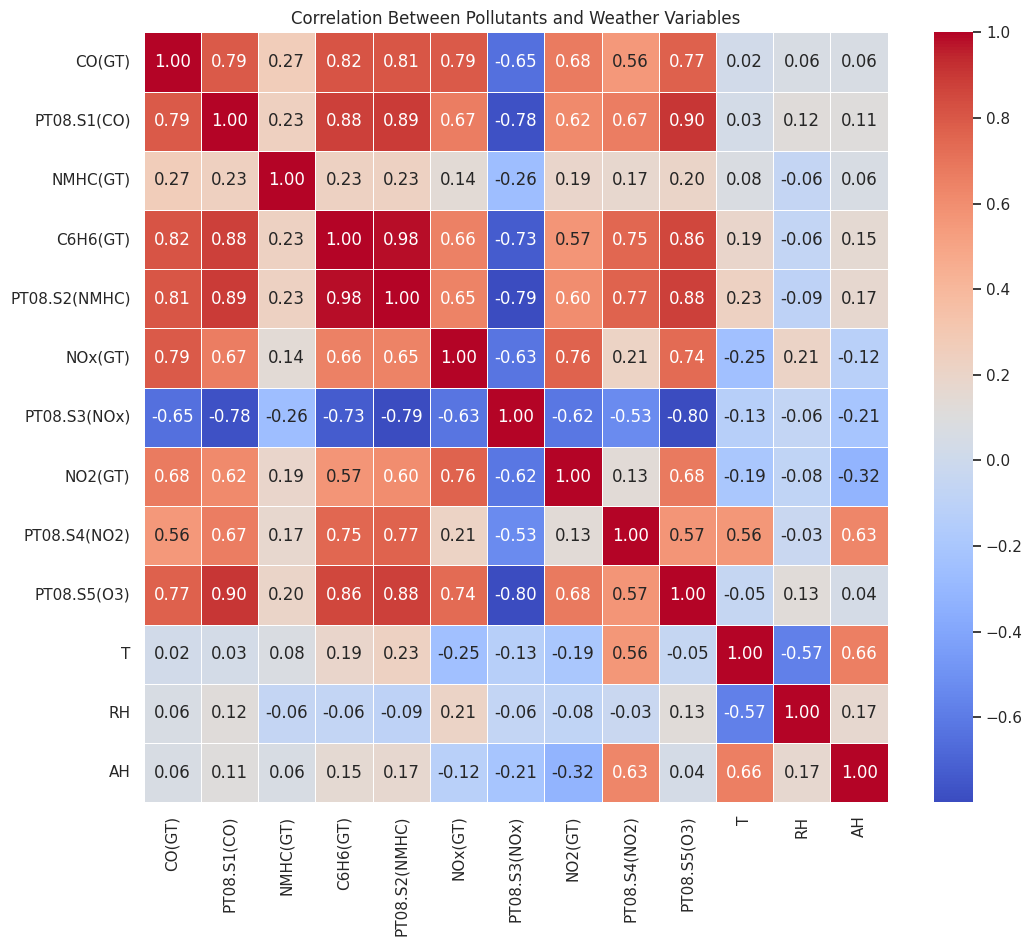

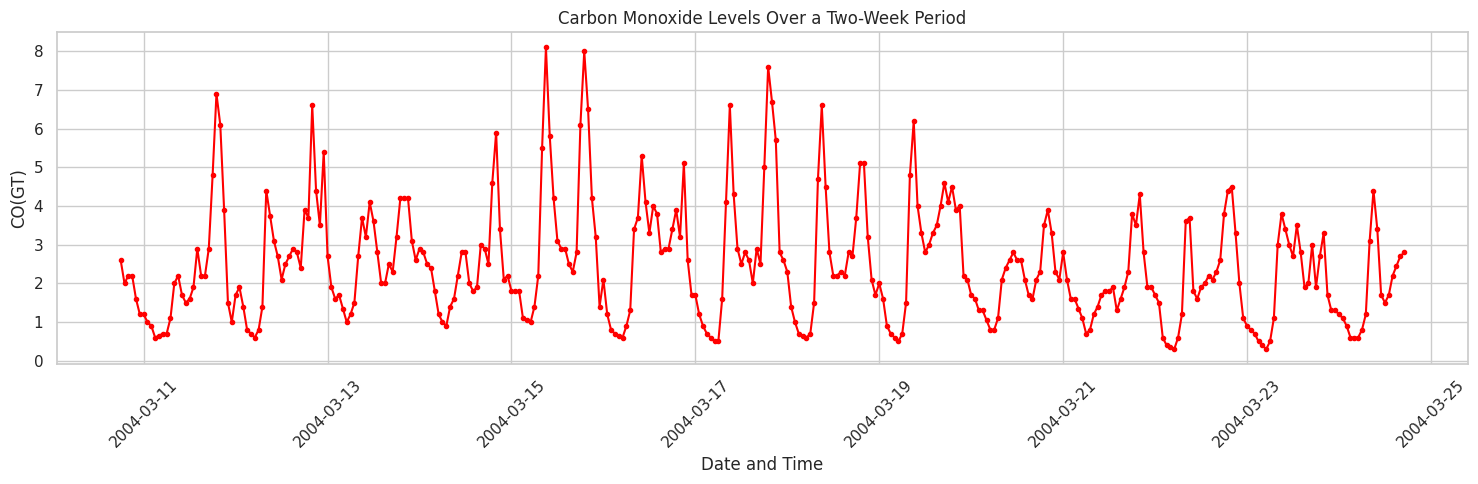

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure our graphs look nice
sns.set_theme(style="whitegrid")

# 1. Distribution of the Target Variable (CO(GT))
plt.figure(figsize=(10, 5))
sns.histplot(df['CO(GT)'], bins=50, kde=True, color='blue')
plt.title('Distribution of Carbon Monoxide CO(GT) Concentrations')
plt.xlabel('CO Concentration (mg/m^3)')
plt.ylabel('Frequency')
plt.show()

# 2. Correlation Heatmap
# This shows how strongly different pollutants and weather features are related
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Pollutants and Weather Variables')
plt.show()

# 3. Time Series trend over 2 weeks
# Plotting the first 336 hours (14 days * 24 hours) to look for repeating patterns
plt.figure(figsize=(15, 5))
plt.plot(df.index[:336], df['CO(GT)'][:336], marker='.', linestyle='-', color='red')
plt.title('Carbon Monoxide Levels Over a Two-Week Period')
plt.xlabel('Date and Time')
plt.ylabel('CO(GT)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# 1. Time-based features
# Extracting specific time components helps the model learn daily and seasonal cycles
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month

# 2. Lagged features (Historical Memory)
# "What was the pollution level exactly 1 hour ago? 2 hours ago? 24 hours ago?"
df['CO_Lag_1'] = df['CO(GT)'].shift(1)
df['CO_Lag_2'] = df['CO(GT)'].shift(2)
df['CO_Lag_24'] = df['CO(GT)'].shift(24)

# 3. Rolling Average feature (Trend indicator)
# "What was the average pollution over the last 6 hours?"
df['CO_Rolling_6'] = df['CO(GT)'].rolling(window=6).mean()

# Because we shifted the data back 24 hours, the first 24 rows now have missing data (NaNs).
# We must drop these empty rows so the model doesn't crash.
df.dropna(inplace=True)

print("New Engineered Data Shape:", df.shape)
# Display the newly added columns at the far right
df[['CO(GT)', 'Hour', 'DayOfWeek', 'CO_Lag_1', 'CO_Lag_24', 'CO_Rolling_6']].head(10)

New Engineered Data Shape: (9333, 20)


,CO(GT),Hour,DayOfWeek,CO_Lag_1,CO_Lag_24,CO_Rolling_6
Datetime,,,,,,
2004-03-11 18:00:00,4.8,18,3,2.9,2.6,2.816667
2004-03-11 19:00:00,6.9,19,3,4.8,2.0,3.650000
2004-03-11 20:00:00,6.1,20,3,6.9,2.2,4.183333
2004-03-11 21:00:00,3.9,21,3,6.1,2.2,4.466667
2004-03-11 22:00:00,1.5,22,3,3.9,1.6,4.350000
2004-03-11 23:00:00,1.0,23,3,1.5,1.2,4.033333
2004-03-12 00:00:00,1.7,0,4,1.0,1.2,3.516667
2004-03-12 01:00:00,1.9,1,4,1.7,1.0,2.683333
2004-03-12 02:00:00,1.4,2,4,1.9,0.9,1.900000


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define target (what we are predicting) and features (what we use to predict)
# We want to predict current CO(GT). We will use all other columns to do it.
target = 'CO(GT)'
X = df.drop(columns=[target])
y = df[target]

# 2. Time-Series Train/Test Split (80% Train, 20% Test)
# CRITICAL: We cannot shuffle time-series data. We must train on the past and test on the future.
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training on {len(X_train)} rows (past), Testing on {len(X_test)} rows (future).")

# 3. Build and Train the Model
# Random Forest is excellent for handling complex, non-linear tabular data
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 4. Make Predictions on the unseen future data
predictions = model.predict(X_test)

# 5. Evaluate the Model's Performance
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\n--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Training on 7466 rows (past), Testing on 1867 rows (future).

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 0.3001
Mean Squared Error (MSE): 0.2063
Root Mean Squared Error (RMSE): 0.4542
R-squared (R2): 0.8920


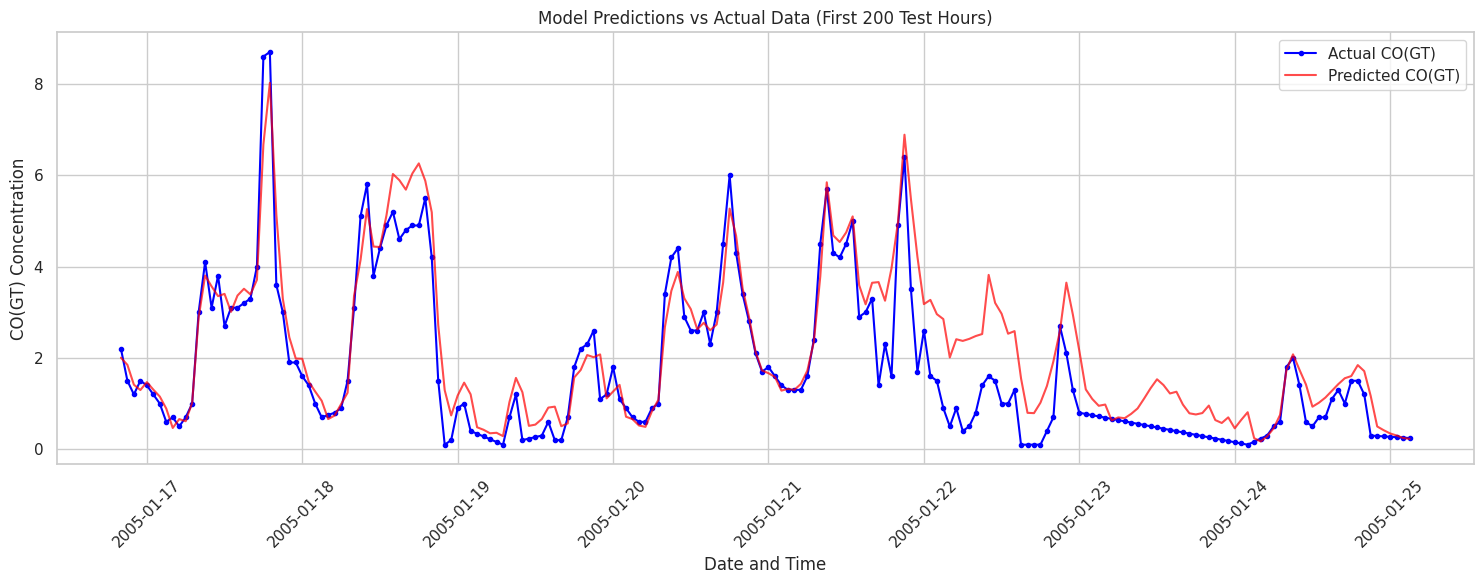

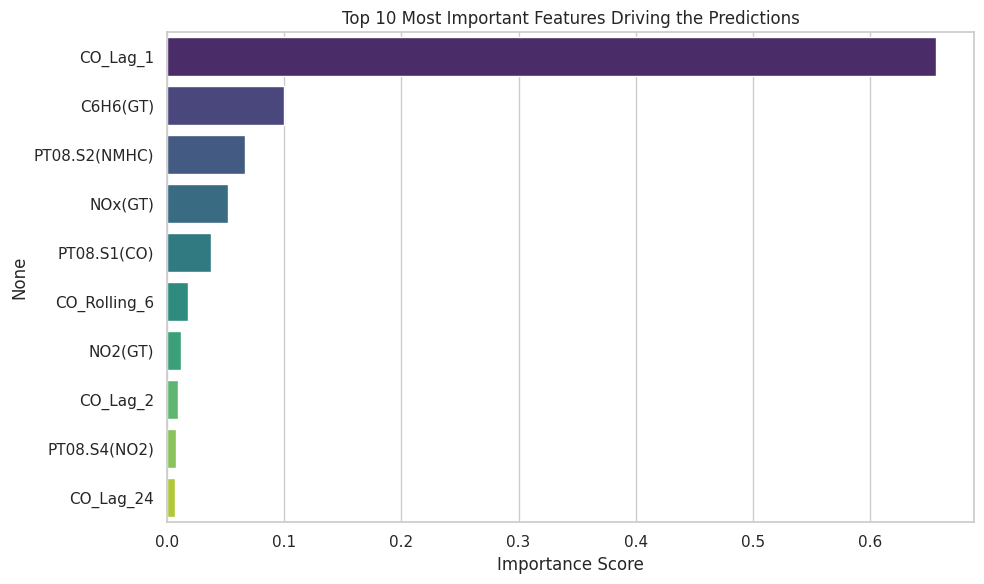

In [6]:
# 1. Plot Actual vs Predicted for the first 200 hours of our test set
plt.figure(figsize=(15, 6))
# Plotting the true values
plt.plot(y_test.index[:200], y_test.values[:200], label='Actual CO(GT)', color='blue', marker='.')
# Plotting our model's predictions
plt.plot(y_test.index[:200], predictions[:200], label='Predicted CO(GT)', color='red', alpha=0.7)

plt.title('Model Predictions vs Actual Data (First 200 Test Hours)')
plt.xlabel('Date and Time')
plt.ylabel('CO(GT) Concentration')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Feature Importance Analysis
# Extracting how much weight the Random Forest gave to each column
feature_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp[:10].values, y=feature_imp[:10].index, hue=feature_imp[:10].index, palette='viridis', legend=False)
plt.title('Top 10 Most Important Features Driving the Predictions')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
'''
Key Findings from the Analysis:
1. Strong Daily Seasonality: The Exploratory Data Analysis clearly showed that Carbon Monoxide levels follow a strict daily rhythm, peaking
heavily during what aligns with morning and evening commute hours.
2. Predictive Power of the Immediate Past: The feature importance chart revealed that the single biggest indicator of current air quality is the
air quality from exactly 1 to 2 hours ago (`CO_Lag_1` and `CO_Lag_2`).
3. Weather Correlation: The heatmap demonstrated that atmospheric conditions like absolute humidity have noticeable correlations with the
concentration of pollutants, meaning weather heavily dictates gas dispersal.
4. Model Consistency: The Random Forest model accurately captures the daily cycle and successfully forecasts the rise and fall of pollution,
proving that historical patterns are a reliable indicator of future air quality.
5. Underestimating Extremes: While the model accurately predicts the general trend, the line graph of Actual vs. Predicted shows that the model
struggles to perfectly hit the peak of sudden, extreme pollution spikes.

Limitations of this Approach:
1. Single Geographic Location: This dataset represents a single localized area in Italy. The patterns the model learned (like specific rush hour
times) cannot be universally applied to a city with different geography, public transit, or work culture.
2. Sensor Degradation: Chemical sensors often degrade or drift over time. Since we only have about a year of data, the model might be learning
subtle sensor errors rather than genuine atmospheric changes.
3. Missing Context: The model lacks crucial external context variables, such as major holidays, sudden traffic accidents, or rainstorms, which
drastically affect local air quality but aren't present in this CSV.

Possible Improvement for Future Work:
Integrating External APIs and Deep Learning: A major improvement would be to merge this dataset with historical weather data (wind speed, rain)
and traffic congestion data. Furthermore, instead of using a Random Forest, we could implement a sequence-based Deep Learning model, such as an **LSTM
(Long Short-Term Memory network)**, which is explicitly designed to retain long-term dependencies in time-series forecasting.
'''